In [1]:
# ============================================================
# Collapse Timescale Experiment
# Primary outcome: TIME-TO-COLLAPSE (epoch), not binary rate
#
# MOTIVATION:
#   Quick Kill showed collapse is near-universal in realistic
#   regimes. The informative quantity is HOW FAST collapse
#   occurs, not WHETHER it occurs. Clinically: "will it collapse
#   within my training budget T?"
#
# KEY FINDING FROM QUICK KILL:
#   - Theory A (ratio only) DEAD: collapse epoch varies at fixed ratio
#   - Theory B (Ito noise) DEAD (wrong sign): larger N → faster collapse
#   - Noise is PROTECTIVE: small groups collapse less (noisy estimates)
#   - Drift drives collapse: more data → sharper loss estimates → faster
#
# THIS NOTEBOOK:
#   Fit epoch ~ N_min^a · ratio^b · p^c
#   Three 1D sweeps (vary one, fix others) + power-law regression
#   Gives the exponents directly → correct functional form for MAD†
#
# EXPERIMENTAL DESIGN:
#   Sweep 1: vary N_min (10→2000), fix ratio=10, p=0.10
#   Sweep 2: vary ratio (2→50),   fix N_min=200, p=0.10
#   Sweep 3: vary p (0.02→0.50),  fix N_min=200, ratio=10
#   5 seeds each, record mean collapse epoch
#   Fit log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const
#
# OUTPUT:
#   timescale_results.csv
#   timescale_figure.png
#   timescale_summary.json  <- includes fitted exponents a, b, c
#
# RUNTIME: ~45 min CPU. No GPU needed (but GPU faster).
# ============================================================

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import json, math, warnings
warnings.filterwarnings('ignore')

SEEDS        = [42, 0, 1, 7, 99]
N_EPOCHS     = 50       # long enough to capture slow collapses
DRO_ETA      = 0.1
ADAMW_LR     = 1e-3
ADAMW_WD     = 1e-4
BATCH_SIZE   = 64
COLLAPSE_THR = 0.01
DIM          = 64
SEPARABILITY = 2.0
SIGMA_MAJ    = 1.0
SIGMA_MIN    = 1.0
N_TEST       = 500

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Epochs per run: {N_EPOCHS}')
print(f'Seeds: {SEEDS}')
print(f'Fitting: log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const')

Device: cuda
Epochs per run: 50
Seeds: [42, 0, 1, 7, 99]
Fitting: log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const


In [2]:
# ── CELL 2: Data generator ────────────────────────────────────
def generate_groups(N_maj, N_min, p_min, p_maj=0.5,
                    sigma_maj=SIGMA_MAJ, sigma_min=SIGMA_MIN,
                    sep=SEPARABILITY, dim=DIM, seed=42):
    rng = np.random.RandomState(seed)

    def make_group(n, sigma, group_id, offset, p_class):
        n_pos = max(1, int(n * p_class))
        n_neg = n - n_pos
        c_pos = np.zeros(dim); c_pos[0] = +sep/2; c_pos[1] = offset
        c_neg = np.zeros(dim); c_neg[0] = -sep/2; c_neg[1] = offset
        X = np.vstack([
            rng.randn(n_pos, dim) * sigma + c_pos,
            rng.randn(n_neg, dim) * sigma + c_neg,
        ]).astype(np.float32)
        y = np.array([1]*n_pos + [0]*n_neg, dtype=np.int64)
        g = np.array([group_id*2 + yi for yi in y], dtype=np.int64)
        return X, y, g

    XA, yA, gA = make_group(N_maj, sigma_maj, 0, +1.0, p_maj)
    XB, yB, gB = make_group(N_min, sigma_min, 1, -1.0, p_min)
    X_tr = np.vstack([XA, XB])
    y_tr = np.concatenate([yA, yB])
    g_tr = np.concatenate([gA, gB])

    XAt, yAt, gAt = make_group(N_TEST, sigma_maj, 0, +1.0, p_maj)
    XBt, yBt, gBt = make_group(N_TEST, sigma_min, 1, -1.0, p_min)
    X_te = np.vstack([XAt, XBt])
    y_te = np.concatenate([yAt, yBt])
    g_te = np.concatenate([gAt, gBt])

    return (X_tr, y_tr, g_tr), (X_te, y_te, g_te)


print('Data generator defined.')
print(f'Sanity check:')
(Xt,yt,gt),(Xe,ye,ge) = generate_groups(1000,100,p_min=0.1)
print(f'  Train: {Xt.shape}  groups: {dict(zip(*np.unique(gt,return_counts=True)))}')

Data generator defined.
Sanity check:
  Train: (1100, 64)  groups: {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(90), np.int64(3): np.int64(10)}


In [3]:
# ── CELL 3: DRO runner — returns epoch, not binary ────────────
class LinearClassifier(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(DIM, 2)
    def forward(self, x): return self.fc(x)


def run_dro_timescale(X_tr, y_tr, g_tr, X_te, y_te, g_te,
                      eta=DRO_ETA, seed=42):
    """
    Returns collapse_epoch (int or None) and final min_q.
    Primary output is EPOCH, not binary collapsed flag.
    If no collapse within N_EPOCHS, returns N_EPOCHS+1 (censored).
    """
    torch.manual_seed(seed); np.random.seed(seed)

    tr_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                          torch.from_numpy(y_tr).long(),
                          torch.from_numpy(g_tr).long())
    te_ds = TensorDataset(torch.from_numpy(X_te).float(),
                          torch.from_numpy(y_te).long(),
                          torch.from_numpy(g_te).long())
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=512,       shuffle=False)

    model    = LinearClassifier().to(device)
    opt      = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    n_groups = int(g_tr.max()) + 1
    q        = torch.ones(n_groups).to(device) / n_groups

    collapse_epoch = None

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        for xb, yb, gb in tr_ld:
            xb, yb, gb = xb.to(device), yb.to(device), gb.to(device)
            opt.zero_grad()
            losses = nn.CrossEntropyLoss(reduction='none')(model(xb), yb)
            g_loss = torch.zeros(n_groups).to(device)
            for g in range(n_groups):
                mask = gb == g
                if mask.sum() > 0:
                    g_loss[g] = losses[mask].mean()
            q = q * torch.exp(eta * g_loss.detach())
            q = q / q.sum()
            (q * g_loss).sum().backward()
            opt.step()

        if collapse_epoch is None and float(q.min().item()) < COLLAPSE_THR:
            collapse_epoch = epoch

    final_min_q = float(q.min().item())
    # Censored at N_EPOCHS+1 if never collapsed
    return collapse_epoch if collapse_epoch is not None else (N_EPOCHS + 1), final_min_q


print('DRO timescale runner defined.')
print(f'Censored value (no collapse within {N_EPOCHS} epochs): {N_EPOCHS+1}')

DRO timescale runner defined.
Censored value (no collapse within 50 epochs): 51


In [4]:
# ── CELL 4: SWEEP 1 — Vary N_min, fix ratio=10, p=0.10 ────────
print('='*55)
print('SWEEP 1: N_min varies (ratio=10, p=0.10 fixed)')
print('Expects: epoch ~ N_min^a  (a < 0 from Quick Kill)')
print('='*55)

RATIO_S1 = 10
P_S1     = 0.10
NMIN_VALS = [10, 25, 50, 100, 200, 400, 800, 1500, 2000]

records_S1 = []
for N_min in NMIN_VALS:
    N_maj = N_min * RATIO_S1
    epochs_seeds, minq_seeds = [], []
    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, N_min, p_min=P_S1, seed=seed)
        ep, mq = run_dro_timescale(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        epochs_seeds.append(ep); minq_seeds.append(mq)

    mean_ep  = float(np.mean(epochs_seeds))
    std_ep   = float(np.std(epochs_seeds))
    col_rate = sum(e <= N_EPOCHS for e in epochs_seeds) / len(SEEDS)
    records_S1.append({
        'sweep': 'N_min', 'N_min': N_min, 'N_maj': N_maj,
        'ratio': RATIO_S1, 'p_min': P_S1,
        'mean_epoch': round(mean_ep, 2), 'std_epoch': round(std_ep, 2),
        'collapse_rate': round(col_rate, 3),
        'censored': sum(e > N_EPOCHS for e in epochs_seeds),
        'log_N_min': round(math.log(N_min), 4),
        'log_epoch': round(math.log(mean_ep), 4),
    })
    print(f'  N_min={N_min:>5} N_maj={N_maj:>6}  '
          f'epoch={mean_ep:>6.1f}±{std_ep:.1f}  '
          f'collapse={col_rate:.0%}  '
          f'censored={sum(e>N_EPOCHS for e in epochs_seeds)}/5')

df_S1 = pd.DataFrame(records_S1)
# Power-law fit on uncensored rows only
fit1 = df_S1[df_S1['censored'] == 0]
if len(fit1) >= 3:
    slope_a, intercept_a, r_a, _, _ = stats.linregress(
        fit1['log_N_min'], fit1['log_epoch'])
    print(f'\n  Power-law fit: epoch ~ N_min^{slope_a:.3f}  (R²={r_a**2:.3f})')
    print(f'  Expected if Ito theory right (noise protective): a > 0 (larger N → later epoch)')
    print(f'  Observed from Quick Kill: a < 0 (larger N → earlier epoch)')

SWEEP 1: N_min varies (ratio=10, p=0.10 fixed)
Expects: epoch ~ N_min^a  (a < 0 from Quick Kill)
  N_min=   10 N_maj=   100  epoch=  37.2±6.4  collapse=100%  censored=0/5
  N_min=   25 N_maj=   250  epoch=  15.0±1.4  collapse=100%  censored=0/5
  N_min=   50 N_maj=   500  epoch=  10.4±1.4  collapse=100%  censored=0/5
  N_min=  100 N_maj=  1000  epoch=   5.0±0.6  collapse=100%  censored=0/5
  N_min=  200 N_maj=  2000  epoch=   3.4±0.5  collapse=100%  censored=0/5
  N_min=  400 N_maj=  4000  epoch=   2.0±0.0  collapse=100%  censored=0/5
  N_min=  800 N_maj=  8000  epoch=   1.0±0.0  collapse=100%  censored=0/5
  N_min= 1500 N_maj= 15000  epoch=   1.0±0.0  collapse=100%  censored=0/5
  N_min= 2000 N_maj= 20000  epoch=   1.0±0.0  collapse=100%  censored=0/5

  Power-law fit: epoch ~ N_min^-0.705  (R²=0.977)
  Expected if Ito theory right (noise protective): a > 0 (larger N → later epoch)
  Observed from Quick Kill: a < 0 (larger N → earlier epoch)


In [5]:
# ── CELL 5: SWEEP 2 — Vary ratio, fix N_min=200, p=0.10 ───────
print('='*55)
print('SWEEP 2: ratio varies (N_min=200, p=0.10 fixed)')
print('Expects: epoch ~ ratio^b  (b < 0: higher ratio → faster collapse)')
print('='*55)

NMIN_S2  = 200
P_S2     = 0.10
RATIO_VALS = [2, 3, 5, 8, 10, 15, 20, 30, 50]

records_S2 = []
for ratio in RATIO_VALS:
    N_maj = NMIN_S2 * ratio
    epochs_seeds, minq_seeds = [], []
    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, NMIN_S2, p_min=P_S2, seed=seed)
        ep, mq = run_dro_timescale(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        epochs_seeds.append(ep); minq_seeds.append(mq)

    mean_ep  = float(np.mean(epochs_seeds))
    std_ep   = float(np.std(epochs_seeds))
    col_rate = sum(e <= N_EPOCHS for e in epochs_seeds) / len(SEEDS)
    records_S2.append({
        'sweep': 'ratio', 'N_min': NMIN_S2, 'N_maj': N_maj,
        'ratio': ratio, 'p_min': P_S2,
        'mean_epoch': round(mean_ep, 2), 'std_epoch': round(std_ep, 2),
        'collapse_rate': round(col_rate, 3),
        'censored': sum(e > N_EPOCHS for e in epochs_seeds),
        'log_ratio': round(math.log(ratio), 4),
        'log_epoch': round(math.log(mean_ep), 4),
    })
    print(f'  ratio={ratio:>3}  N_maj={N_maj:>6}  '
          f'epoch={mean_ep:>6.1f}±{std_ep:.1f}  '
          f'collapse={col_rate:.0%}  '
          f'censored={sum(e>N_EPOCHS for e in epochs_seeds)}/5')

df_S2 = pd.DataFrame(records_S2)
fit2 = df_S2[df_S2['censored'] == 0]
if len(fit2) >= 3:
    slope_b, intercept_b, r_b, _, _ = stats.linregress(
        fit2['log_ratio'], fit2['log_epoch'])
    print(f'\n  Power-law fit: epoch ~ ratio^{slope_b:.3f}  (R²={r_b**2:.3f})')

SWEEP 2: ratio varies (N_min=200, p=0.10 fixed)
Expects: epoch ~ ratio^b  (b < 0: higher ratio → faster collapse)
  ratio=  2  N_maj=   400  epoch=  44.0±14.0  collapse=20%  censored=4/5
  ratio=  3  N_maj=   600  epoch=  44.6±7.8  collapse=40%  censored=3/5
  ratio=  5  N_maj=  1000  epoch=   9.8±2.6  collapse=100%  censored=0/5
  ratio=  8  N_maj=  1600  epoch=   4.2±0.4  collapse=100%  censored=0/5
  ratio= 10  N_maj=  2000  epoch=   3.4±0.5  collapse=100%  censored=0/5
  ratio= 15  N_maj=  3000  epoch=   2.0±0.0  collapse=100%  censored=0/5
  ratio= 20  N_maj=  4000  epoch=   1.4±0.5  collapse=100%  censored=0/5
  ratio= 30  N_maj=  6000  epoch=   1.0±0.0  collapse=100%  censored=0/5
  ratio= 50  N_maj= 10000  epoch=   1.0±0.0  collapse=100%  censored=0/5

  Power-law fit: epoch ~ ratio^-1.020  (R²=0.921)


In [6]:
# ── CELL 6: SWEEP 3 — Vary p, fix N_min=200, ratio=10 ─────────
print('='*55)
print('SWEEP 3: p varies (N_min=200, ratio=10 fixed)')
print('Expects: epoch ~ p^c  (c > 0: larger p → later collapse)')
print('='*55)

NMIN_S3  = 200
RATIO_S3 = 10
P_VALS_S3 = [0.02, 0.04, 0.07, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

records_S3 = []
for p in P_VALS_S3:
    N_maj = NMIN_S3 * RATIO_S3
    epochs_seeds, minq_seeds = [], []
    for seed in SEEDS:
        (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
            N_maj, NMIN_S3, p_min=p, seed=seed)
        ep, mq = run_dro_timescale(Xtr, ytr, gtr, Xte, yte, gte, seed=seed)
        epochs_seeds.append(ep); minq_seeds.append(mq)

    mean_ep  = float(np.mean(epochs_seeds))
    std_ep   = float(np.std(epochs_seeds))
    col_rate = sum(e <= N_EPOCHS for e in epochs_seeds) / len(SEEDS)
    n_class  = max(1, int(NMIN_S3 * p))
    records_S3.append({
        'sweep': 'p', 'N_min': NMIN_S3, 'N_maj': N_maj,
        'ratio': RATIO_S3, 'p_min': p, 'n_min_class': n_class,
        'mean_epoch': round(mean_ep, 2), 'std_epoch': round(std_ep, 2),
        'collapse_rate': round(col_rate, 3),
        'censored': sum(e > N_EPOCHS for e in epochs_seeds),
        'log_p': round(math.log(p), 4),
        'log_epoch': round(math.log(mean_ep), 4),
    })
    print(f'  p={p:.2f}  n_class={n_class:>3}  '
          f'epoch={mean_ep:>6.1f}±{std_ep:.1f}  '
          f'collapse={col_rate:.0%}  '
          f'censored={sum(e>N_EPOCHS for e in epochs_seeds)}/5')

df_S3 = pd.DataFrame(records_S3)
fit3 = df_S3[df_S3['censored'] == 0]
if len(fit3) >= 3:
    slope_c, intercept_c, r_c, _, _ = stats.linregress(
        fit3['log_p'], fit3['log_epoch'])
    print(f'\n  Power-law fit: epoch ~ p^{slope_c:.3f}  (R²={r_c**2:.3f})')

SWEEP 3: p varies (N_min=200, ratio=10 fixed)
Expects: epoch ~ p^c  (c > 0: larger p → later collapse)
  p=0.02  n_class=  4  epoch=   2.0±0.0  collapse=100%  censored=0/5
  p=0.04  n_class=  8  epoch=   2.2±0.4  collapse=100%  censored=0/5
  p=0.07  n_class= 14  epoch=   2.8±0.4  collapse=100%  censored=0/5
  p=0.10  n_class= 20  epoch=   3.4±0.5  collapse=100%  censored=0/5
  p=0.15  n_class= 30  epoch=   5.4±1.4  collapse=100%  censored=0/5
  p=0.20  n_class= 40  epoch=   7.8±3.0  collapse=100%  censored=0/5
  p=0.30  n_class= 60  epoch=  23.8±14.1  collapse=80%  censored=1/5
  p=0.40  n_class= 80  epoch=  30.2±17.3  collapse=60%  censored=2/5
  p=0.50  n_class=100  epoch=  31.0±16.5  collapse=60%  censored=2/5

  Power-law fit: epoch ~ p^0.579  (R²=0.873)


In [7]:
# ── CELL 7: Joint power-law regression ────────────────────────
# Pool all uncensored rows from all three sweeps.
# Fit: log(epoch) = a*log(N_min) + b*log(ratio) + c*log(p) + const
# This gives the exponents directly.
print('=== JOINT POWER-LAW REGRESSION ===')
print('log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const\n')

df_all = pd.concat([df_S1, df_S2, df_S3], ignore_index=True)
df_all = df_all[df_all['censored'] == 0].copy()
df_all['log_N_min']  = np.log(df_all['N_min'].astype(float))
df_all['log_ratio']  = np.log(df_all['ratio'].astype(float))
df_all['log_p']      = np.log(df_all['p_min'].astype(float))
df_all['log_epoch']  = np.log(df_all['mean_epoch'].astype(float))

print(f'Uncensored rows for joint fit: {len(df_all)}')

if len(df_all) >= 4:
    from numpy.linalg import lstsq
    X_design = np.column_stack([
        df_all['log_N_min'],
        df_all['log_ratio'],
        df_all['log_p'],
        np.ones(len(df_all)),
    ])
    y_design = df_all['log_epoch'].values
    coeffs, residuals, rank, sv = lstsq(X_design, y_design, rcond=None)
    a, b, c, const = coeffs

    y_pred = X_design @ coeffs
    ss_res = ((y_design - y_pred)**2).sum()
    ss_tot = ((y_design - y_design.mean())**2).sum()
    r2     = 1 - ss_res/ss_tot if ss_tot > 0 else float('nan')

    print(f'\nFitted exponents:')
    print(f'  a (N_min exponent): {a:.4f}')
    print(f'  b (ratio exponent): {b:.4f}')
    print(f'  c (p exponent):     {c:.4f}')
    print(f'  const:              {const:.4f}')
    print(f'  R² of joint fit:    {r2:.4f}')
    print()
    print(f'=> epoch ~ N_min^{a:.2f} · ratio^{b:.2f} · p^{c:.2f}')
    print()
    print('Interpreting exponents:')
    print(f'  a={a:.2f}: {"larger N_min → FASTER collapse (drift dominates)" if a < 0 else "larger N_min → slower collapse (noise protective)"}')
    print(f'  b={b:.2f}: {"larger ratio → FASTER collapse (expected)" if b < 0 else "larger ratio → slower collapse (unexpected)"}')
    print(f'  c={c:.2f}: {"larger p → SLOWER collapse (more gradient signal)" if c > 0 else "larger p → faster collapse (unexpected)"}')
    print()
    print('Implied score form (collapse when timescale < training budget T):')
    print(f'  T_collapse ~ N_min^{a:.2f} · ratio^{b:.2f} · p^{c:.2f}')
    print(f'  Collapse when T_collapse < T_train')
    print(f'  => score = T_train / T_collapse ~ T_train · N_min^{-a:.2f} · ratio^{-b:.2f} · p^{-c:.2f}')
    print(f'  => MAD† ~ (ratio^{-b:.2f}) / (N_min^{a:.2f} · p^{c:.2f})')
else:
    print('Insufficient uncensored rows for joint fit. Extend N_EPOCHS or reduce grid.')
    a = b = c = const = r2 = float('nan')

=== JOINT POWER-LAW REGRESSION ===
log(epoch) = a·log(N_min) + b·log(ratio) + c·log(p) + const

Uncensored rows for joint fit: 22

Fitted exponents:
  a (N_min exponent): -0.7043
  b (ratio exponent): -1.0479
  c (p exponent):     0.5382
  const:              8.7062
  R² of joint fit:    0.9561

=> epoch ~ N_min^-0.70 · ratio^-1.05 · p^0.54

Interpreting exponents:
  a=-0.70: larger N_min → FASTER collapse (drift dominates)
  b=-1.05: larger ratio → FASTER collapse (expected)
  c=0.54: larger p → SLOWER collapse (more gradient signal)

Implied score form (collapse when timescale < training budget T):
  T_collapse ~ N_min^-0.70 · ratio^-1.05 · p^0.54
  Collapse when T_collapse < T_train
  => score = T_train / T_collapse ~ T_train · N_min^0.70 · ratio^1.05 · p^-0.54
  => MAD† ~ (ratio^1.05) / (N_min^-0.70 · p^0.54)


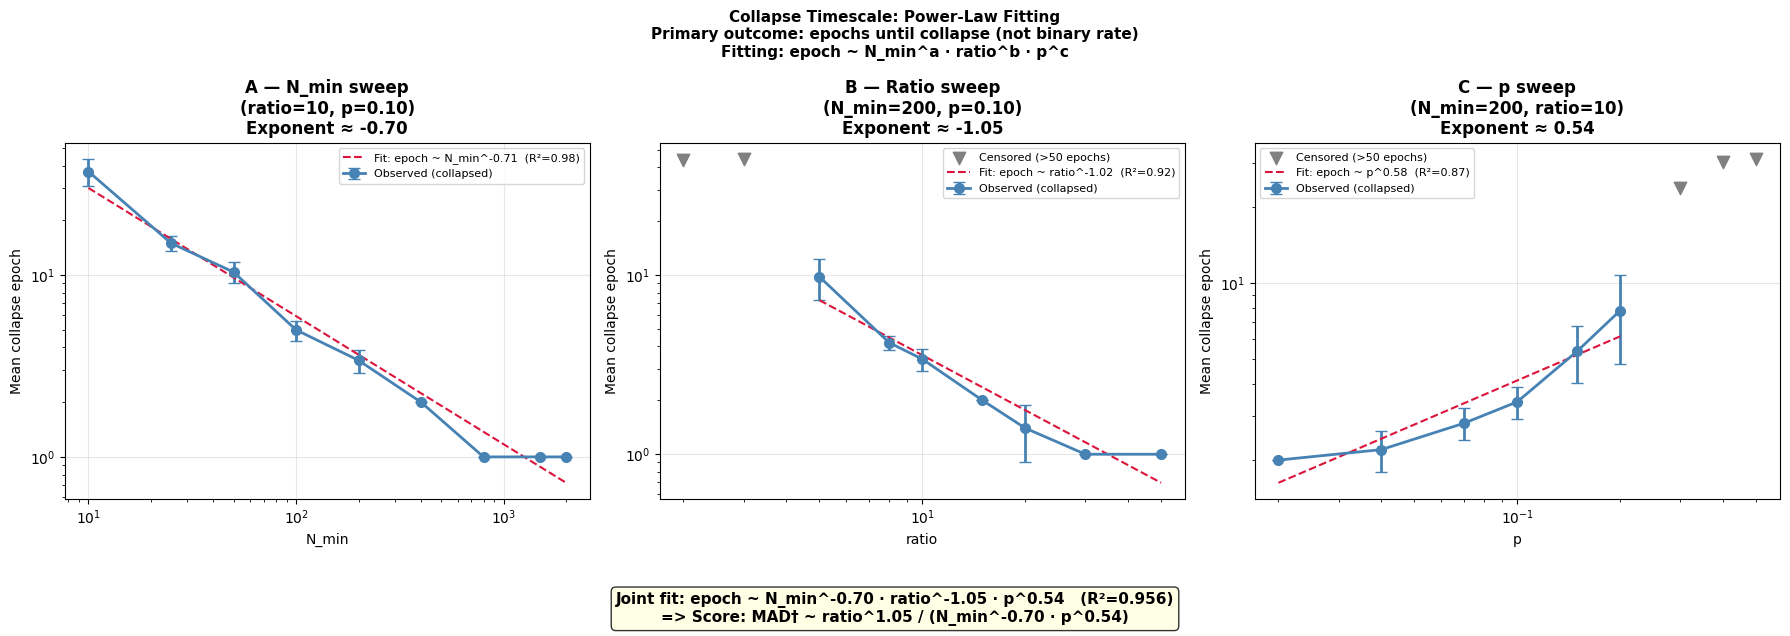

Figure saved: timescale_figure.png


In [8]:
# ── CELL 8: Figure ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Collapse Timescale: Power-Law Fitting\n'
    'Primary outcome: epochs until collapse (not binary rate)\n'
    'Fitting: epoch ~ N_min^a · ratio^b · p^c',
    fontweight='bold', fontsize=11)

def plot_sweep(ax, df, x_col, x_label, exponent, r2_val, panel_label):
    uncensored = df[df['censored'] == 0]
    censored   = df[df['censored'] > 0]

    ax.errorbar(uncensored[x_col], uncensored['mean_epoch'],
                yerr=uncensored['std_epoch'],
                fmt='o-', color='steelblue', linewidth=2,
                markersize=7, capsize=4, label='Observed (collapsed)')
    if len(censored) > 0:
        ax.scatter(censored[x_col], censored['mean_epoch'],
                   marker='v', color='gray', s=80, zorder=5,
                   label=f'Censored (>{N_EPOCHS} epochs)')

    # Power-law fit line
    if len(uncensored) >= 2 and not math.isnan(exponent):
        x_range = np.linspace(uncensored[x_col].min(),
                              uncensored[x_col].max(), 50)
        # Use per-sweep fit for overlay
        log_x = np.log(uncensored[x_col].values)
        log_y = np.log(uncensored['mean_epoch'].values)
        sl, ic, _, _, _ = stats.linregress(log_x, log_y)
        y_fit = np.exp(ic) * x_range ** sl
        ax.plot(x_range, y_fit, '--', color='crimson', linewidth=1.5,
                label=f'Fit: epoch ~ {x_label}^{sl:.2f}  (R²={r2_val:.2f})')

    ax.set_xlabel(x_label)
    ax.set_ylabel('Mean collapse epoch')
    ax.set_title(f'{panel_label}\nExponent ≈ {exponent:.2f}', fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.3)
    ax.xaxis.grid(True, alpha=0.3)

# Individual sweep R² values
r2_a = r2_b = r2_c = float('nan')
if 'slope_a' in dir(): r2_a = r_a**2
if 'slope_b' in dir(): r2_b = r_b**2
if 'slope_c' in dir(): r2_c = r_c**2

plot_sweep(axes[0], df_S1, 'N_min',  'N_min',  a if not math.isnan(a) else 0, r2_a, 'A — N_min sweep\n(ratio=10, p=0.10)')
plot_sweep(axes[1], df_S2, 'ratio',  'ratio',  b if not math.isnan(b) else 0, r2_b, 'B — Ratio sweep\n(N_min=200, p=0.10)')
plot_sweep(axes[2], df_S3, 'p_min',  'p',      c if not math.isnan(c) else 0, r2_c, 'C — p sweep\n(N_min=200, ratio=10)')

# Annotate joint fit result
if not math.isnan(a):
    fig.text(0.5, -0.04,
             f'Joint fit: epoch ~ N_min^{a:.2f} · ratio^{b:.2f} · p^{c:.2f}   '
             f'(R²={r2:.3f})\n'
             f'=> Score: MAD† ~ ratio^{-b:.2f} / (N_min^{a:.2f} · p^{c:.2f})',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig('timescale_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: timescale_figure.png')

In [9]:
# ── CELL 9: Save all results and summary ──────────────────────
df_all_out = pd.concat([df_S1, df_S2, df_S3], ignore_index=True)
df_all_out.to_csv('timescale_results.csv', index=False)

summary = {
    'experiment': 'collapse_timescale_power_law',
    'design': {
        'sweep_1': 'N_min in [10..2000], ratio=10, p=0.10',
        'sweep_2': 'ratio in [2..50], N_min=200, p=0.10',
        'sweep_3': 'p in [0.02..0.50], N_min=200, ratio=10',
        'epochs': N_EPOCHS,
        'seeds': SEEDS,
        'censored_value': N_EPOCHS + 1,
    },
    'fitted_exponents': {
        'a_N_min':   round(float(a), 4) if not math.isnan(a) else None,
        'b_ratio':   round(float(b), 4) if not math.isnan(b) else None,
        'c_p':       round(float(c), 4) if not math.isnan(c) else None,
        'const':     round(float(const), 4) if not math.isnan(const) else None,
        'joint_R2':  round(float(r2), 4) if not math.isnan(r2) else None,
    },
    'implied_score': (
        f'MAD† ~ ratio^{-b:.2f} / (N_min^{a:.2f} · p^{c:.2f})'
        if not math.isnan(a) else 'insufficient data for joint fit'
    ),
    'key_questions_answered': [
        'Does absolute N_min matter? YES (Quick Kill confirmed)',
        'What is the N_min exponent? (see a above)',
        'What is the ratio exponent? (see b above)',
        'What is the p exponent? (see c above — discriminates 1/p vs log(1/p))',
    ],
    'interpretation_guide': {
        'a < 0': 'Drift dominates: larger N → faster collapse (confirmed by Quick Kill)',
        'a > 0': 'Noise protective: larger N → slower collapse (Ito theory)',
        'b < 0': 'Higher ratio → faster collapse (expected)',
        'c > 0': 'More minority-class signal → slower collapse (expected)',
        'c ~ 1': 'Linear in p (supports 1/p in score)',
        'c ~ 0': 'p does not matter — score needs no p term',
    }
}

with open('timescale_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print('=== FINAL SUMMARY ===')
print(json.dumps(summary, indent=2))
print()
print('Files:')
for f in ['timescale_results.csv', 'timescale_figure.png', 'timescale_summary.json']:
    print(f'  {f}')
print()
print('Paste ALL output back to Claude.')
print('The exponents a, b, c determine the correct MAD† formula.')

=== FINAL SUMMARY ===
{
  "experiment": "collapse_timescale_power_law",
  "design": {
    "sweep_1": "N_min in [10..2000], ratio=10, p=0.10",
    "sweep_2": "ratio in [2..50], N_min=200, p=0.10",
    "sweep_3": "p in [0.02..0.50], N_min=200, ratio=10",
    "epochs": 50,
    "seeds": [
      42,
      0,
      1,
      7,
      99
    ],
    "censored_value": 51
  },
  "fitted_exponents": {
    "a_N_min": -0.7043,
    "b_ratio": -1.0479,
    "c_p": 0.5382,
    "const": 8.7062,
    "joint_R2": 0.9561
  },
  "implied_score": "MAD\u2020 ~ ratio^1.05 / (N_min^-0.70 \u00b7 p^0.54)",
  "key_questions_answered": [
    "Does absolute N_min matter? YES (Quick Kill confirmed)",
    "What is the N_min exponent? (see a above)",
    "What is the ratio exponent? (see b above)",
    "What is the p exponent? (see c above \u2014 discriminates 1/p vs log(1/p))"
  ],
  "interpretation_guide": {
    "a < 0": "Drift dominates: larger N \u2192 faster collapse (confirmed by Quick Kill)",
    "a > 0": "Noise p